# README du Projet d'Analyse Financière de l'Action Attijariwafa Bank (ATW)

Ce projet Colab vise à effectuer une analyse financière approfondie des données historiques de l'action Attijariwafa Bank (ATW). L'objectif est de nettoyer, transformer et enrichir les données brutes, de calculer des indicateurs financiers clés et de visualiser les performances, pour finalement préparer un jeu de données structuré et prêt à l'emploi pour des outils de Business Intelligence comme SQL Server ou Power BI.

## 📊 Étapes du Projet :

### 1. Chargement et Nettoyage des Données Brutes

- **Source de Données** : Les données historiques de l'action ATW sont chargées à partir d'un fichier CSV (`Datos históricos de Attijariwafa Bank (ATW).csv`) situé sur Google Drive.
- **Renommage des Colonnes** : Les noms des colonnes sont standardisés en anglais pour faciliter l'analyse (`Fecha` devient `Date`, `Último` devient `Close`, `Vol.` devient `Volume`, etc.).
- **Conversion des Types de Données** :
    - La colonne `Date` est convertie en format datetime.
    - Les colonnes de prix (`Close`, `Open`, `High`, `Low`) sont nettoyées (remplacement des virgules par des points) et converties en nombres flottants.
    - La colonne `Volume` est nettoyée (gestion des suffixes 'K' et 'M' pour des milliers et millions) et convertie en flottant.
    - La colonne `% var.` (`Pct_Change`) est nettoyée (suppression du '%' et remplacement des virgules) et convertie en pourcentage flottant.
- **Tri des Données** : Le DataFrame est trié par date croissante pour assurer la cohérence des calculs chronologiques.

### 2. Calcul des Indicateurs Financiers Clés

Après le nettoyage, plusieurs métriques financières essentielles sont calculées et ajoutées au DataFrame :

- **Rendement Journalier (`Daily_Return`)** : Le pourcentage de changement du prix de clôture d'un jour à l'autre.
- **Rendement Cumulé (`Cumulative_Return`)** : La performance totale de l'action sur la période analysée.
- **Range Journalier (`Range`)** : La différence entre le prix le plus haut et le plus bas de la journée.
- **Moyennes Mobiles (`MA20`, `MA50`, `MA200`)** : Moyennes des prix de clôture sur 20, 50 et 200 jours, utilisées pour identifier les tendances.
- **Volatilité** : Mesure du degré de variation du prix de l'action, calculée à la fois journalièrement et annuellement.
- **Drawdown (`Drawdown`)** : Représente la perte maximale subie par un investissement par rapport à son sommet précédent.
- **Ratio de Sharpe** : Mesure le rendement excédentaire par unité de risque, par rapport à un taux sans risque (fixé à 2% annuel ici).

### 3. Analyse et Visualisation

Plusieurs visualisations graphiques sont générées pour faciliter la compréhension des données et des performances de l'action :

- **Évolution du Cours et des Moyennes Mobiles** : Permet de suivre la tendance du prix et d'identifier les signaux de trading potentiels.
- **Rendement Cumulé** : Visualise la croissance de l'investissement au fil du temps.
- **Drawdown** : Montre les périodes de baisse significative et l'ampleur des pertes potentielles.
- **Distribution des Rendements Journaliers** : Un histogramme pour comprendre la fréquence des différents niveaux de rendements journaliers.
- **Volume vs. Cours** : Met en relation l'activité de trading (volume) avec les mouvements de prix.

### 4. Résumé des Métriques Clés

Un tableau de bord des indicateurs financiers est imprimé, incluant :

- Volatilité journalière et annuelle.
- Drawdown maximal.
- Ratio de Sharpe annuel.
- Rendement cumulé sur toute la période.
- Statistiques descriptives complètes des prix (moyenne, min, max, écart-type, etc.).
- Les 5 meilleurs et 5 pires jours en termes de rendement journalier.

### 5. Exportation vers SQL Server / Power BI

Le résultat final de ce projet est un fichier CSV (`ATW_financial_final.csv`) qui regroupe toutes les données originales nettoyées et enrichies par les indicateurs financiers calculés. Ce fichier est spécifiquement préparé pour être facilement importé dans des bases de données SQL Server ou des outils de Business Intelligence comme Power BI, permettant des analyses ultérieures, la création de tableaux de bord interactifs et la génération de rapports.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Le chemin correct de votre fichier CSV.
file_path = '/content/drive/MyDrive/Datos históricos de Attijariwafa Bank (ATW).csv'

Mounted at /content/drive


In [ ]:
import pandas as pd

try:
    # Lecture du fichier CSV
    df = pd.read_csv(file_path)

    print("--- Aperçu des 5 premières lignes avant conversion ---")
    print(df.head())
    print("\n" + "-"*40 + "\n")

    print("--- Informations sur les colonnes et leurs types avant conversion ---")
    df.info()
    print("\n" + "-"*40 + "\n")

    # --- Nettoyage et conversion des types de données ---

    # 1. Convertir 'Fecha' en datetime
    # Supposer le format de date JJ.MM.AAAA ou similaire
    df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y', errors='coerce')

    # 2. Nettoyer et convertir les colonnes numériques (prix)
    # Remplacer la virgule par un point et convertir en float
    cols_to_float = ['Último', 'Apertura', 'Máximo', 'Mínimo']
    for col in cols_to_float:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)

    # 3. Nettoyer et convertir la colonne 'Vol.'
    # Supprimer 'K', convertir en float et multiplier par 1000
    def clean_volume(vol_str):
        if isinstance(vol_str, str):
            vol_str = vol_str.replace(',', '.') # Handle comma as decimal separator
            if 'K' in vol_str:
                return float(vol_str.replace('K', '')) * 1000
            elif 'M' in vol_str:
                return float(vol_str.replace('M', '')) * 1000000
            else:
                return float(vol_str)
        return vol_str # Return as is if not string (e.g. NaN)

    df['Vol.'] = df['Vol.'].apply(clean_volume)

    # 4. Nettoyer et convertir la colonne '% var.'
    # Supprimer '%', remplacer la virgule par un point et convertir en float, puis diviser par 100
    df['% var.'] = df['% var.'].str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float) / 100

    print("--- Aperçu des 5 premières lignes après conversion ---")
    print(df.head())
    print("\n" + "-"*40 + "\n")

    print("--- Informations sur les colonnes et leurs types après conversion ---")
    df.info()
    print("\n" + "-"*40 + "\n")

    print("--- Statistiques descriptives après conversion ---")
    print(df.describe(include='all'))
    print("\n" + "-"*40 + "\n")

except FileNotFoundError:
    print(f"Erreur: Le fichier n'a pas été trouvé à l'emplacement: {file_path}")
    print("Veuillez vérifier que le chemin du fichier est correct et que le fichier existe dans votre Google Drive.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement ou de l'analyse du fichier : {e}")

--- Aperçu des 5 premières lignes avant conversion ---
        Fecha  Último Apertura  Máximo  Mínimo     Vol.  % var.
0  27.02.2026  726,00   739,00  745,00  726,00  121,93K  -1,76%
1  26.02.2026  739,00   746,20  749,00  732,00   26,96K  -1,34%
2  25.02.2026  749,00   754,00  754,00  746,30   18,76K  -0,65%
3  24.02.2026  753,90   751,00  755,00  751,00   20,48K  -0,15%
4  23.02.2026  755,00   751,00  755,00  751,00    7,34K  -0,66%

----------------------------------------

--- Informations sur les colonnes et leurs types avant conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Fecha     2027 non-null   object
 1   Último    2027 non-null   object
 2   Apertura  2027 non-null   object
 3   Máximo    2027 non-null   object
 4   Mínimo    2027 non-null   object
 5   Vol.      2027 non-null   object
 6   % var.    2027 non-null   object


In [ ]:
# Renommer les colonnes en anglais
df.rename(columns={
    "Fecha": "Date",
    "Último": "Close",
    "Apertura": "Open",
    "Máximo": "High",
    "Mínimo": "Low",
    "Vol.": "Volume",
    "% var.": "Pct_Change"
}, inplace=True)

# Vérification
df.head()

,Date,Close,Open,High,Low,Volume,Pct_Change
0,2026-02-27,726.0,739.0,745.0,726.0,121930.0,-0.0176
1,2026-02-26,739.0,746.2,749.0,732.0,26960.0,-0.0134
2,2026-02-25,749.0,754.0,754.0,746.3,18760.0,-0.0065
3,2026-02-24,753.9,751.0,755.0,751.0,20480.0,-0.0015
4,2026-02-23,755.0,751.0,755.0,751.0,7340.0,-0.0066


In [ ]:
# Vérifier les valeurs manquantes
print(df.isna().sum())

# Vérifier les doublons
print(df.duplicated().sum())

# Vérifier les valeurs aberrantes (exemple simple)
print(df.describe())

Date          0
Close         0
Open          0
High          0
Low           0
Volume        0
Pct_Change    0
dtype: int64
0
                                Date        Close         Open         High  \
count                           2027  2027.000000  2027.000000  2027.000000   
mean   2022-01-29 19:50:38.776516864   489.665096   489.042649   492.870474   
min              2018-01-02 00:00:00   318.100000   320.000000   325.000000   
25%              2020-01-21 12:00:00   431.125000   431.000000   434.950000   
50%              2022-02-03 00:00:00   467.000000   465.050000   469.000000   
75%              2024-02-07 12:00:00   505.000000   504.900000   507.350000   
max              2026-02-27 00:00:00   789.900000   790.000000   804.000000   
std                              NaN   101.094078   100.639209   101.992264   

               Low        Volume   Pct_Change  
count  2027.000000  2.027000e+03  2027.000000  
mean    486.250937  6.002080e+04     0.000270  
min     317.45000

In [ ]:
# Rendement journalier
df['Daily_Return'] = df['Close'].pct_change()

# Rendement cumulé
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

# Range journalier
df['Range'] = df['High'] - df['Low']

# Moyennes mobiles
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

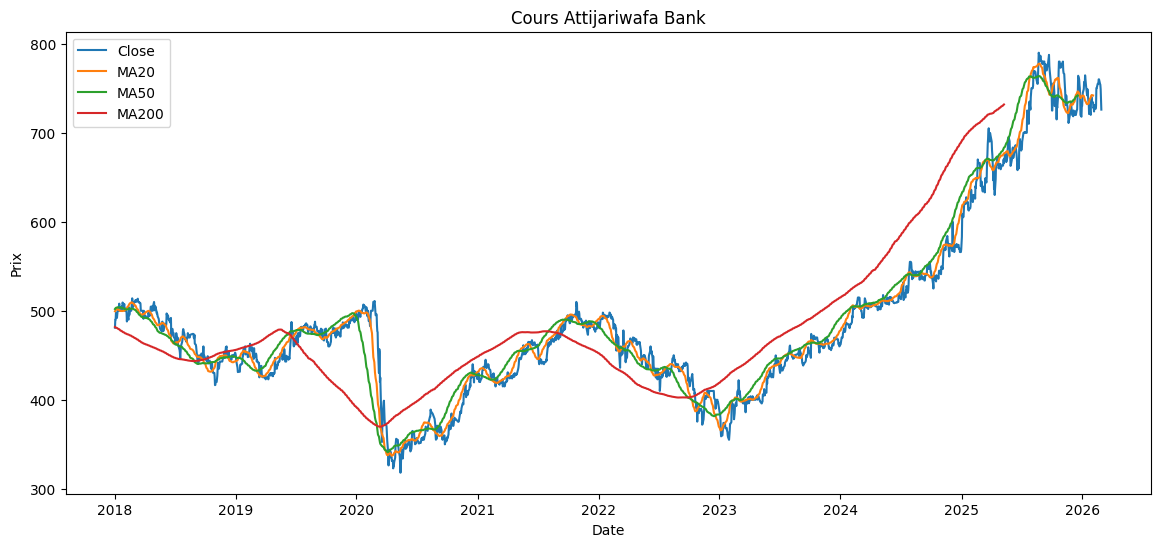

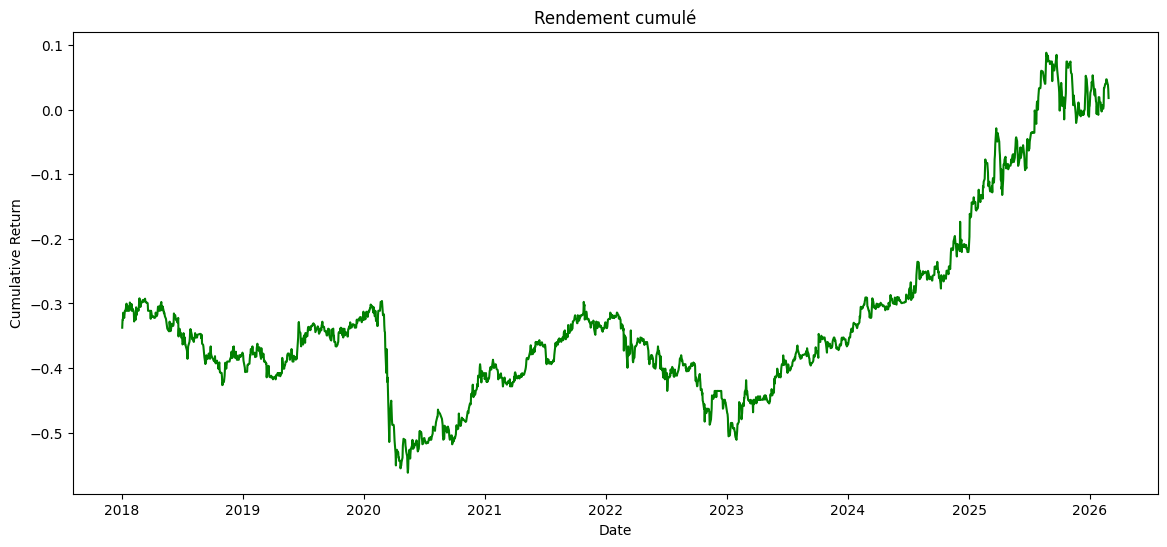

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.plot(df['Date'], df['MA200'], label='MA200')
plt.title('Cours Attijariwafa Bank')
plt.xlabel('Date')
plt.ylabel('Prix')
plt.legend()
plt.show()

# Rendement cumulé
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Cumulative_Return'], color='green')
plt.title('Rendement cumulé')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

In [ ]:
# Volatilité journalière (std des rendements)
daily_vol = df['Daily_Return'].std()
print("Volatilité journalière:", daily_vol)

# Volatilité annuelle approximative
annual_vol = daily_vol * (252**0.5)  # 252 jours de bourse par an
print("Volatilité annuelle:", annual_vol)

Volatilité journalière: 0.011902852198969364
Volatilité annuelle: 0.18895192086498744


In [ ]:
# Drawdown (perte maximale cumulée)
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()
df['Drawdown'] = df['Cumulative_Return'] / df['Cumulative_Return'].cummax() - 1
max_drawdown = df['Drawdown'].min()
print("Drawdown maximum :", max_drawdown)

Drawdown maximum : -0.5972907963033294


In [ ]:
risk_free_rate = 0.02 / 252  # 2% taux sans risque annuel, converti en journalier
sharpe_ratio = (df['Daily_Return'].mean() - risk_free_rate) / daily_vol * (252**0.5)
print("Ratio de Sharpe annuel :", sharpe_ratio)

Ratio de Sharpe annuel : -0.2827411890164659


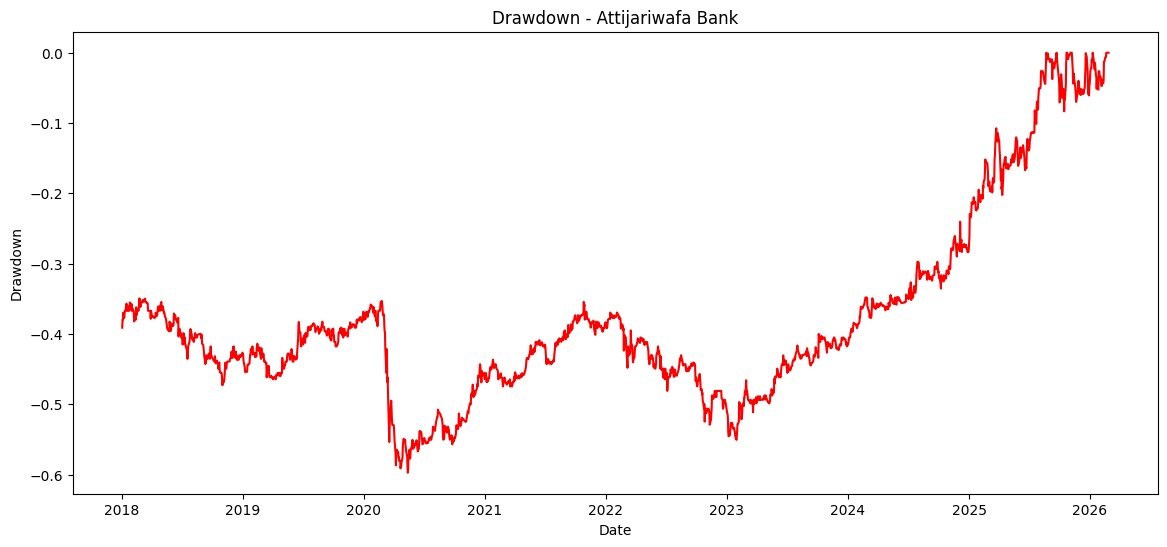

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Drawdown'], color='red')
plt.title('Drawdown - Attijariwafa Bank')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

===== METRICS FINANCIÈRES =====
Volatilité journalière : 0.0118
Volatilité annuelle : 0.1881
Drawdown max : -0.3811
Ratio de Sharpe annuel : 0.2602
Rendement cumulé sur la période : 50.94%


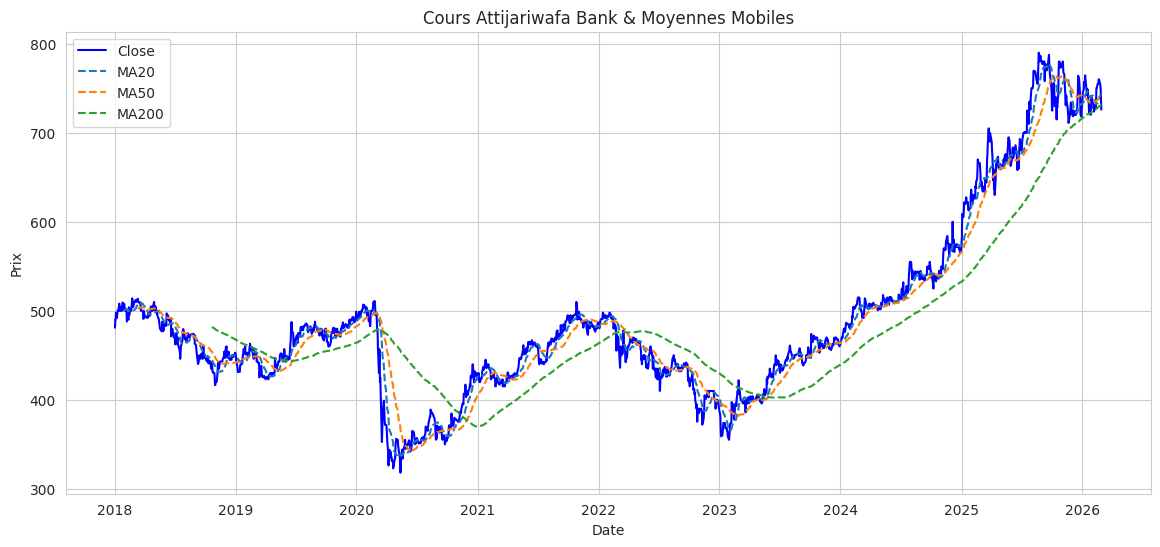

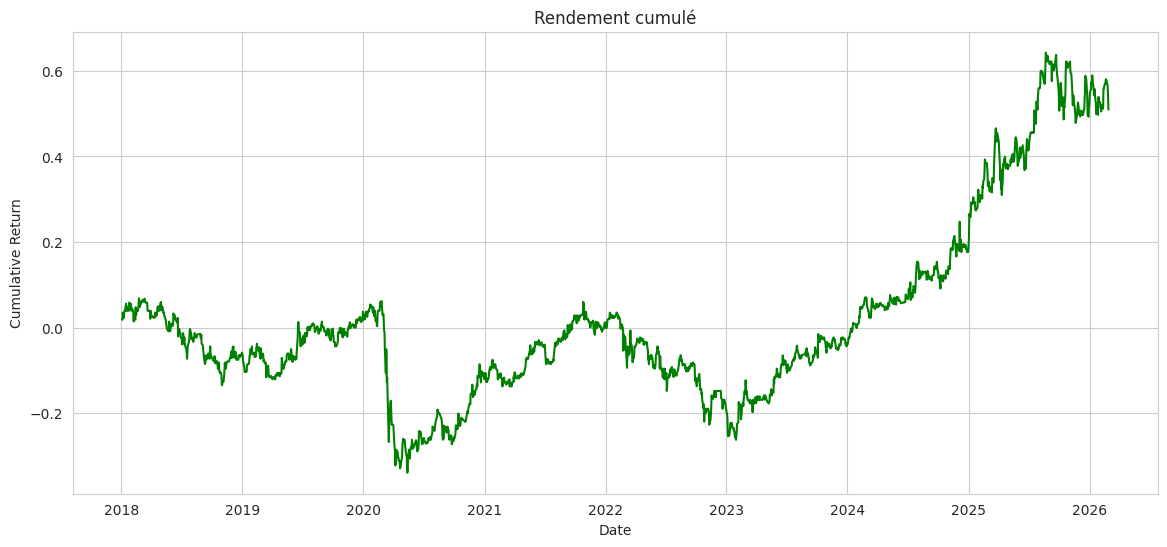

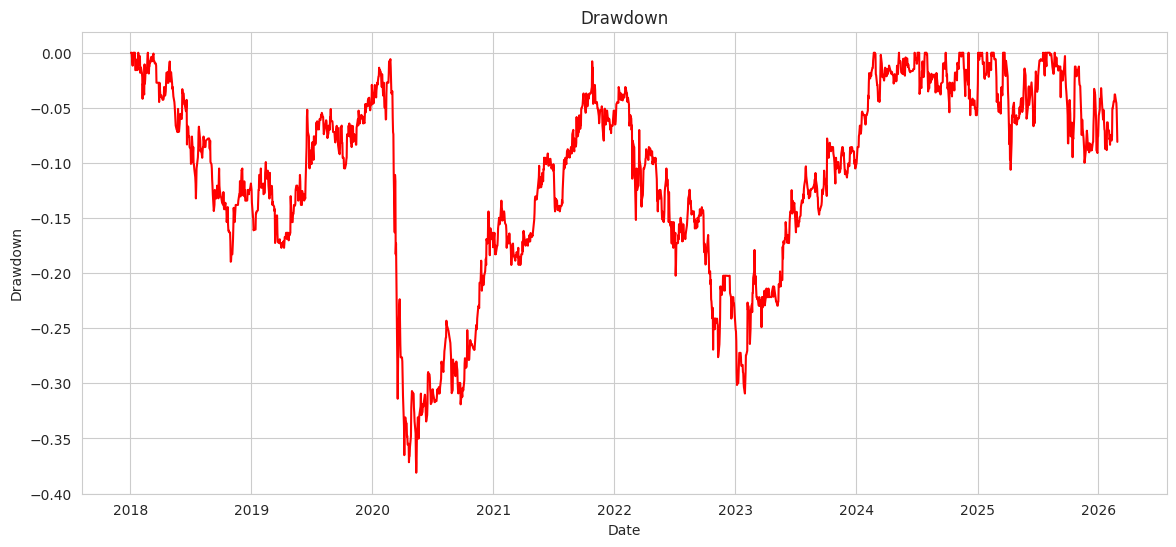

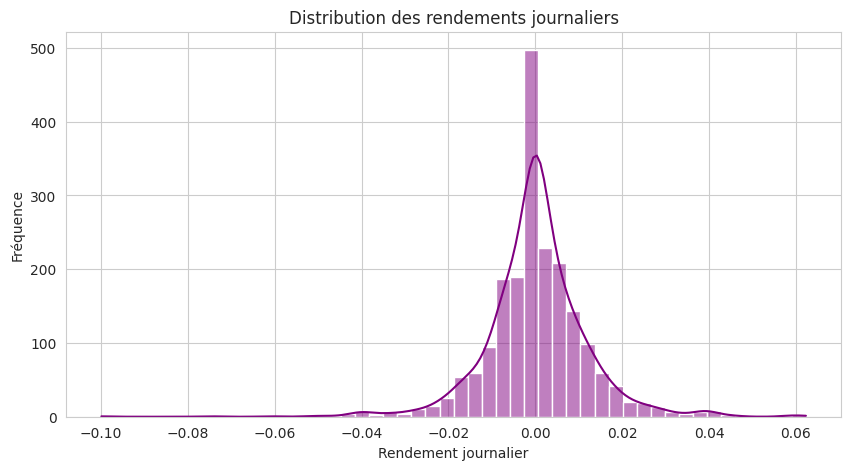

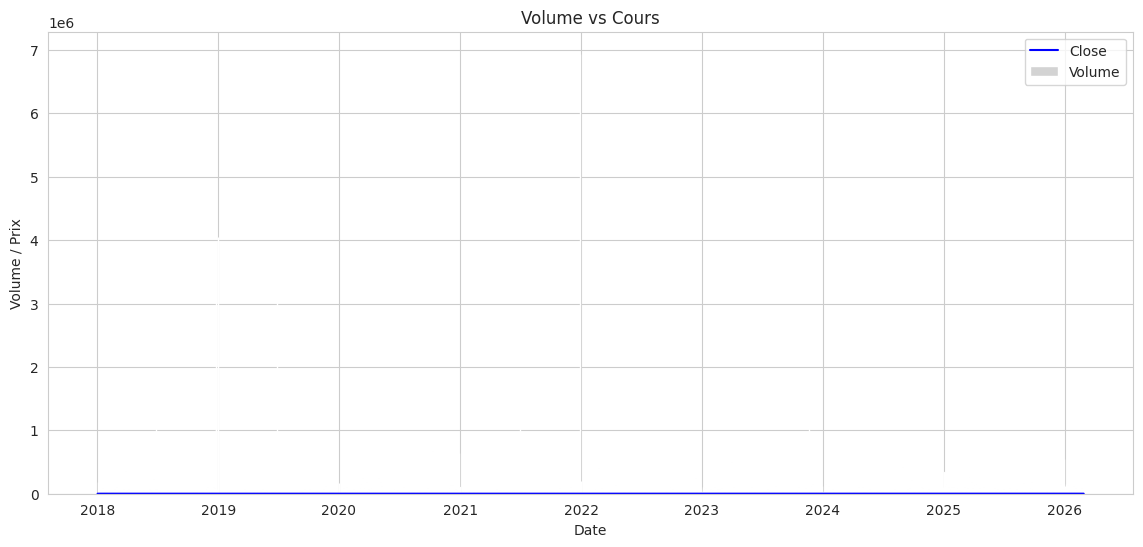

In [ ]:
# Import des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------------------------
# 1️⃣ Lecture et préparation du dataset
# ---------------------------
df = pd.read_csv(file_path)

# Renommer les colonnes en anglais
df.rename(columns={
    "Fecha": "Date",
    "Último": "Close",
    "Apertura": "Open",
    "Máximo": "High",
    "Mínimo": "Low",
    "Vol.": "Volume",
    "% var.": "Pct_Change"
}, inplace=True)

# Conversion des types de données avec nettoyage

# Convertir 'Date' en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')

# Nettoyer et convertir les colonnes numériques (prix)
# Remplacer la virgule par un point et convertir en float
cols_to_float_price = ['Close', 'Open', 'High', 'Low']
for col in cols_to_float_price:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Nettoyer et convertir la colonne 'Volume'
# Supprimer 'K' ou 'M', convertir en float et multiplier par 1000 ou 1000000
def clean_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.replace(',', '.') # Gérer la virgule comme séparateur décimal si présente
        if 'K' in vol_str:
            return float(vol_str.replace('K', '')) * 1000
        elif 'M' in vol_str:
            return float(vol_str.replace('M', '')) * 1000000
        else:
            return float(vol_str)
    return vol_str # Retourner tel quel si ce n'est pas une chaîne (ex: NaN)

df['Volume'] = df['Volume'].apply(clean_volume)

# Nettoyer et convertir la colonne 'Pct_Change'
# Supprimer '%', remplacer la virgule par un point et convertir en float, puis diviser par 100
df['Pct_Change'] = df['Pct_Change'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float) / 100

# Trier par date croissante
df = df.sort_values('Date').reset_index(drop=True)

# ---------------------------
# 2️⃣ Calcul des métriques essentielles
# ---------------------------

# Rendement journalier
df['Daily_Return'] = df['Close'].pct_change()

# Rendement cumulé
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

# Range journalier
df['Range'] = df['High'] - df['Low']

# Moyennes mobiles
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Volatilité
daily_vol = df['Daily_Return'].std()
annual_vol = daily_vol * (252**0.5)

# Drawdown
df['Cumulative_Return_temp'] = (1 + df['Daily_Return']).cumprod()
df['Drawdown'] = df['Cumulative_Return_temp'] / df['Cumulative_Return_temp'].cummax() - 1
max_drawdown = df['Drawdown'].min()

# Ratio de Sharpe
risk_free_rate = 0.02 / 252
sharpe_ratio = (df['Daily_Return'].mean() - risk_free_rate) / daily_vol * (252**0.5)

# ---------------------------
# 3️⃣ Affichage métriques principales
# ---------------------------
print("===== METRICS FINANCIÈRES =====")
print(f"Volatilité journalière : {daily_vol:.4f}")
print(f"Volatilité annuelle : {annual_vol:.4f}")
print(f"Drawdown max : {max_drawdown:.4f}")
print(f"Ratio de Sharpe annuel : {sharpe_ratio:.4f}")
print(f"Rendement cumulé sur la période : {df['Cumulative_Return'].iloc[-1]:.2%}")

# ---------------------------
# 4️⃣ Graphiques essentiels
# ---------------------------

# 4a) Evolution du cours et MA
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label='Close', color='blue')
plt.plot(df['Date'], df['MA20'], label='MA20', linestyle='--')
plt.plot(df['Date'], df['MA50'], label='MA50', linestyle='--')
plt.plot(df['Date'], df['MA200'], label='MA200', linestyle='--')
plt.title('Cours Attijariwafa Bank & Moyennes Mobiles')
plt.xlabel('Date')
plt.ylabel('Prix')
plt.legend()
plt.show()

# 4b) Rendement cumulé
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Cumulative_Return'], color='green')
plt.title('Rendement cumulé')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# 4c) Drawdown
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Drawdown'], color='red')
plt.title('Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.show()

# 4d) Distribution des rendements journaliers
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution des rendements journaliers')
plt.xlabel('Rendement journalier')
plt.ylabel('Fréquence')
plt.show()

# 4e) Volume vs Close
plt.figure(figsize=(14,6))
plt.bar(df['Date'], df['Volume'], color='lightgrey', label='Volume')
plt.plot(df['Date'], df['Close'], color='blue', label='Close')
plt.title('Volume vs Cours')
plt.xlabel('Date')
plt.ylabel('Volume / Prix')
plt.legend()
plt.show()

In [ ]:
# Import des librairies
import pandas as pd
import numpy as np

# ---------------------------
# 1️⃣ Lecture et préparation
# ---------------------------
df = pd.read_csv(file_path) # Correction ici: utilisation de file_path

# Renommer les colonnes en anglais
df.rename(columns={
    "Fecha": "Date",
    "Último": "Close",
    "Apertura": "Open",
    "Máximo": "High",
    "Mínimo": "Low",
    "Vol.": "Volume",
    "% var.": "Pct_Change"
}, inplace=True)

# Conversion des types de données avec nettoyage (ajout du nettoyage complet)

# Convertir 'Date' en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')

# Nettoyer et convertir les colonnes numériques (prix)
# Remplacer la virgule par un point et convertir en float
cols_to_float_price = ['Close', 'Open', 'High', 'Low']
for col in cols_to_float_price:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Nettoyer et convertir la colonne 'Volume'
# Supprimer 'K' ou 'M', convertir en float et multiplier par 1000 ou 1000000
def clean_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.replace(',', '.') # Gérer la virgule comme séparateur décimal si présente
        if 'K' in vol_str:
            return float(vol_str.replace('K', '')) * 1000
        elif 'M' in vol_str:
            return float(vol_str.replace('M', '')) * 1000000
        else:
            return float(vol_str)
    return vol_str # Retourner tel quel si ce n'est pas une chaîne (ex: NaN)

df['Volume'] = df['Volume'].apply(clean_volume)

# Nettoyer et convertir la colonne 'Pct_Change'
# Supprimer '%', remplacer la virgule par un point et convertir en float, puis diviser par 100
df['Pct_Change'] = df['Pct_Change'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float) / 100

# Trier par date croissante
df = df.sort_values('Date').reset_index(drop=True)

# ---------------------------
# 2️⃣ Calcul des indicateurs essentiels
# ---------------------------

# Rendement journalier et cumulé
df['Daily_Return'] = df['Close'].pct_change()

# Rendement cumulé
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1

# Range journalier
df['Range'] = df['High'] - df['Low']

# Moyennes mobiles
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

# Volatilité
daily_vol = df['Daily_Return'].std()
annual_vol = daily_vol * np.sqrt(252)

# Drawdown
df['Cumulative_Return_temp'] = (1 + df['Daily_Return']).cumprod()
df['Drawdown'] = df['Cumulative_Return_temp'] / df['Cumulative_Return_temp'].cummax() - 1
max_drawdown = df['Drawdown'].min()

# Ratio de Sharpe (annualisé)
risk_free_rate = 0.02 / 252
sharpe_ratio = (df['Daily_Return'].mean() - risk_free_rate) / daily_vol * np.sqrt(252)

# Résumé statistique des prix
summary_stats = df[['Close','Open','High','Low','Volume']].describe()

# ---------------------------
# 3️⃣ Affichage senior-ready
# ---------------------------

print("===== INDICATEURS FINANCIERS SENIOR ====")
print(f"Volatilité journalière : {daily_vol:.4f}")
print(f"Volatilité annuelle : {annual_vol:.4f}")
print(f"Drawdown maximum : {max_drawdown:.4f}")
print(f"Ratio de Sharpe annuel : {sharpe_ratio:.4f}")
print(f"Rendement cumulé sur la période : {df['Cumulative_Return'].iloc[-1]:.2%}")

print("\n===== STATISTIQUES DES PRIX =====")
print(summary_stats)

print("\n===== TOP 5 JOURS AVEC PLUS HAUT REND. =====")
print(df[['Date','Daily_Return']].sort_values('Daily_Return', ascending=False).head())

print("\n===== TOP 5 JOURS AVEC PLUS FAIBLE REND. =====")
print(df[['Date','Daily_Return']].sort_values('Daily_Return').head())

===== INDICATEURS FINANCIERS SENIOR ====
Volatilité journalière : 0.0118
Volatilité annuelle : 0.1881
Drawdown maximum : -0.3811
Ratio de Sharpe annuel : 0.2602
Rendement cumulé sur la période : 50.94%

===== STATISTIQUES DES PRIX =====
             Close         Open         High          Low        Volume
count  2027.000000  2027.000000  2027.000000  2027.000000  2.027000e+03
mean    489.665096   489.042649   492.870474   486.250937  6.002080e+04
std     101.094078   100.639209   101.992264    99.963955  2.337269e+05
min     318.100000   320.000000   325.000000   317.450000  1.000000e+01
25%     431.125000   431.000000   434.950000   429.975000  1.298500e+04
50%     467.000000   465.050000   469.000000   463.100000  2.824000e+04
75%     505.000000   504.900000   507.350000   502.050000  5.615000e+04
max     789.900000   790.000000   804.000000   781.000000  6.940000e+06

===== TOP 5 JOURS AVEC PLUS HAUT REND. =====
           Date  Daily_Return
540  2020-03-10      0.062297
1433 2023

In [ ]:
# Sélection des colonnes nécessaires pour SQL Server / Power BI
final_df = df[[
    'Date',
    'Close',
    'Open',
    'High',
    'Low',
    'Volume',
    'Pct_Change',
    'Daily_Return',
    'Cumulative_Return',
    'Drawdown',
    'MA20',
    'MA50',
    'MA200'
]]

# Vérification rapide
print(final_df.head())

# Export vers CSV prêt pour SQL Server / Power BI
final_df.to_csv("ATW_financial_final.csv", index=False)
print("Fichier final CSV prêt pour SQL Server et Power BI : ATW_financial_final.csv")

        Date   Close   Open    High    Low    Volume  Pct_Change  \
0 2018-01-02  481.00  480.0  481.00  480.0    2020.0     -0.0062   
1 2018-01-03  490.00  484.0  490.00  484.0  185000.0      0.0187   
2 2018-01-04  490.00  490.0  499.00  490.0    1960.0      0.0000   
3 2018-01-05  497.85  490.1  497.85  490.1    8130.0      0.0160   
4 2018-01-08  492.00  491.0  492.00  491.0      70.0     -0.0118   

   Daily_Return  Cumulative_Return  Drawdown  MA20  MA50  MA200  
0           NaN                NaN       NaN   NaN   NaN    NaN  
1      0.018711           0.018711  0.000000   NaN   NaN    NaN  
2      0.000000           0.018711  0.000000   NaN   NaN    NaN  
3      0.016020           0.035031  0.000000   NaN   NaN    NaN  
4     -0.011751           0.022869 -0.011751   NaN   NaN    NaN  
Fichier final CSV prêt pour SQL Server et Power BI : ATW_financial_final.csv


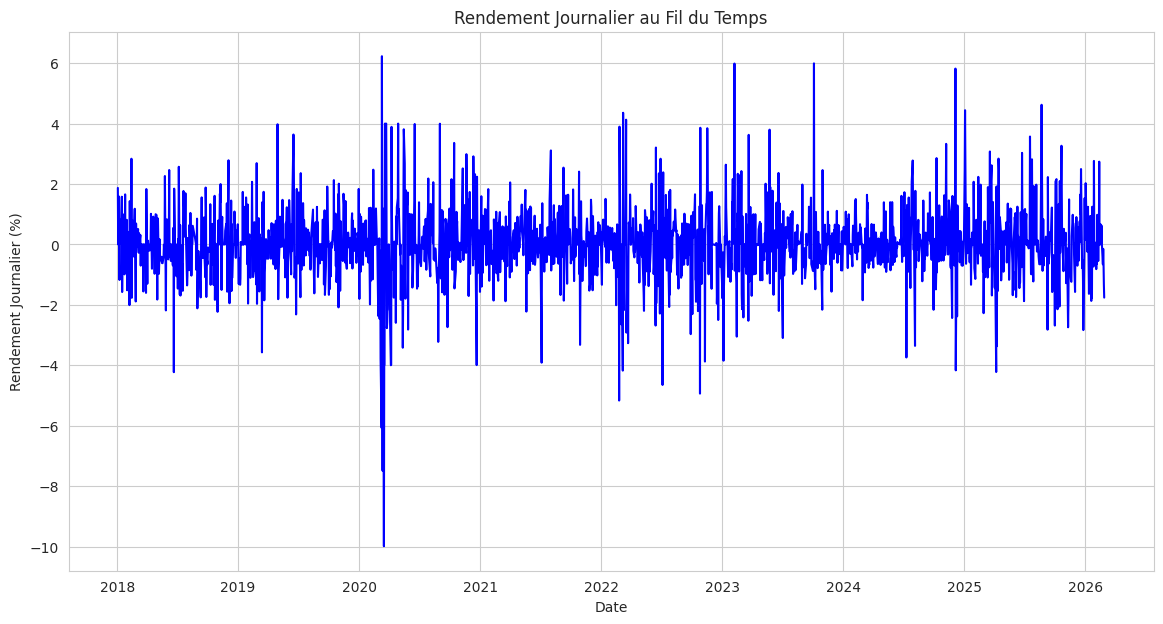

Ce graphique montre l'évolution du rendement journalier en pourcentage au fil du temps.
Si vous souhaitiez plutôt un histogramme de la *distribution* des rendements journaliers (nombre d'occurrences par plage de rendements), veuillez me le faire savoir.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Répétition du chargement et de la préparation de df pour assurer sa disponibilité ---
# Ces lignes devraient être exécutées après le montage de Drive et la définition de file_path
# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Renommer les colonnes en anglais
df.rename(columns={
    "Fecha": "Date",
    "Último": "Close",
    "Apertura": "Open",
    "Máximo": "High",
    "Mínimo": "Low",
    "Vol.": "Volume",
    "% var.": "Pct_Change"
}, inplace=True)

# Conversion des types de données avec nettoyage
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y', errors='coerce')
cols_to_float_price = ['Close', 'Open', 'High', 'Low']
for col in cols_to_float_price:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

def clean_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.replace(',', '.')
        if 'K' in vol_str:
            return float(vol_str.replace('K', '')) * 1000
        elif 'M' in vol_str:
            return float(vol_str.replace('M', '')) * 1000000
        else:
            return float(vol_str)
    return vol_str
df['Volume'] = df['Volume'].apply(clean_volume)

df['Pct_Change'] = df['Pct_Change'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float) / 100

df = df.sort_values('Date').reset_index(drop=True)

# Calcul du Rendement journalier
df['Daily_Return'] = df['Close'].pct_change()
# ---------------------------------------------------------------------------------------

plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Daily_Return'] * 100, color='blue') # Multiplier par 100 pour afficher en pourcentage
plt.title('Rendement Journalier au Fil du Temps')
plt.xlabel('Date')
plt.ylabel('Rendement Journalier (%)')
plt.grid(True)
plt.show()

print("Ce graphique montre l'évolution du rendement journalier en pourcentage au fil du temps.")
print("Si vous souhaitiez plutôt un histogramme de la *distribution* des rendements journaliers (nombre d'occurrences par plage de rendements), veuillez me le faire savoir.")